# 03 Classical Machine Learning: Logistic Regression & PCA

Reproduce the HLOP's rank-classification results (Table 1) and the PCA projections (Figs 2, 4, 5). "Confidence" in the paper's Table 1 is the Matthews correlation coefficient (MCC).

In [1]:
%load_ext autoreload
%autoreload 2
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from murmurations import ml
from murmurations.plots import plot_pc1_weights, plot_pca

DATA = Path("..") / "data"
ec_7500_10000 = pd.read_parquet(DATA / "ec_7500_10000_r012_1000ap.parquet")
ec_1_100000 = pd.read_parquet(DATA / "ec_1_100000_balanced20k_1000ap.parquet")
ec_10000_40000 = pd.read_parquet(
    DATA / "ec_10000_40000_balanced_1000ap.parquet"
)

### Warm-up: Conductor [7500, 10000]

The narrow-range dataset from notebook 01. Note the class sizes are natural (4328 / 5194 / 771), so the (0,2) and (1,2) experiments balance down to 771 curves per class.

In [2]:
for pair in [(0, 1), (0, 2), (1, 2), (0, 1, 2)]:
    r = ml.logistic_experiment(
        ec_7500_10000, ranks=list(pair), n_features=1000, seed=0
    )
    print(f"ranks {pair}: acc={r.accuracy:.3f}  mcc={r.mcc:.3f}")

ranks (0, 1): acc=0.988  mcc=0.975
ranks (0, 2): acc=0.992  mcc=0.985
ranks (1, 2): acc=0.984  mcc=0.969
ranks (0, 1, 2): acc=0.879  mcc=0.819


### HLOP Table 1 reproduction: conductor [1, 10⁵], 20k curves per rank

Same setup as the HLOP's Table 1. Side by side:

<center>

| Ranks     | HLOP's Acc | Our Acc  | HLOP's MCC | Our MCC |
|-----------|------------|----------|------------|---------|
| {0, 1}    | 0.961      | 0.960    | 0.92       | 0.92    |
| {0, 2}    | 0.996      | 0.993    | 0.99       | 0.99    |
| {1, 2}    | 0.999      | 0.999    | 0.99       | 1.00    |
| {0, 1, 2} | 0.975      | 0.974    | 0.96       | 0.96    |

</center>

Agreement within sampling noise. The {0,2} result is the paper's headline: both ranks have even root number, so the separation cannot come from parity.

In [3]:
for pair in [(0, 1), (0, 2), (1, 2), (0, 1, 2)]:
    r = ml.logistic_experiment(
        ec_1_100000, ranks=list(pair), n_features=1000, seed=0
    )
    print(f"ranks {pair}: acc={r.accuracy:.3f}  mcc={r.mcc:.2f}")

ranks (0, 1): acc=0.960  mcc=0.92
ranks (0, 2): acc=0.993  mcc=0.99
ranks (1, 2): acc=0.999  mcc=1.00
ranks (0, 1, 2): acc=0.974  mcc=0.96


### PCA Projection Onto $\mathbb{R}^2$

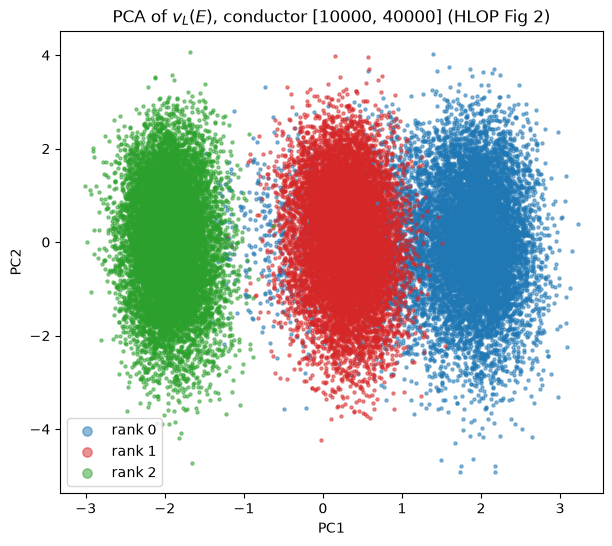

In [4]:
pca_fig2 = ml.pca_2d(ec_10000_40000, ranks=[0, 1, 2], n_features=1000)
plot_pca(
    pca_fig2, title="PCA of $v_L(E)$, conductor [10000, 40000] (HLOP Fig 2)"
)
plt.show()

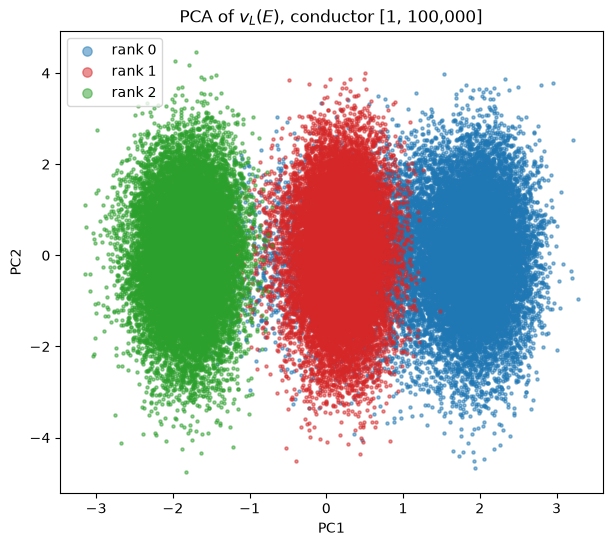

In [5]:
pca_1_100000 = ml.pca_2d(ec_1_100000, ranks=[0, 1, 2], n_features=1000)
plot_pca(pca_1_100000, title="PCA of $v_L(E)$, conductor [1, 100,000]")
plt.show()

### PC1 weights: the decaying oscillation (HLOP Fig 5)

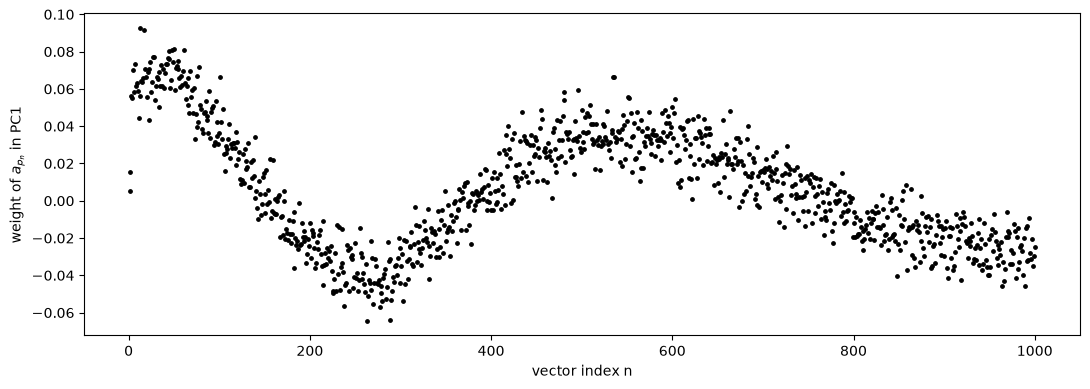

In [6]:
pca01 = ml.pca_2d(ec_7500_10000, ranks=[0, 1], n_features=1000)
plot_pc1_weights(pca01)
plt.tight_layout()
plt.show()

**Note on Sign:** Principal components are eigenvectors, which are defined modulo scalars; i.e., $w$ and $-w$ describe the same axis and explain the same variance. Which sign an implementation returns is an internal convention (`scikit-learn` uses `svd_flip`), so this plot may appear reflected across the $x$-axis relative to the HLOP's Fig 5. The oscillation pattern and relative magnitudes are what's meaningful; the overall sign is not.

### Low-Dimensional Heuristics: HLOP Section 5

Since ~100% of curves are conjecturally rank 0 or 1, HLOP frame the following classification problem in Section 5: whether a curve is "typical" (rank $\leq$ 1) or "unusual" (rank $\geq$ 2). Using only the first 10 primes to construct a feature vector $(a_{2}(E), \dots , a_{29}(E)) \in \mathbb{R}^{10}$, HLOP report ~0.95 accuracy on elliptic curves with conductor in [10000, 20000] and ~0.97 on those with conductor in [1, 10000].

We reproduce the [1, 10000] experiment and additionally run the much wider range [1, 100000], where accuracy drops to  ~0.89: the first ten $a_p$ statistics are conductor-dependent, so pooling a wide window mixes differently-shaped distributions and dilutes the signal.

In [7]:
heur_datasets = {
    "[1, 1e4]": pd.read_parquet(DATA / "ec_1_10000_r0123_1000ap.parquet"),
    "[7500, 1e4]": ec_7500_10000,
    "[1, 1e5]": ec_1_100000,
}
for name, d in heur_datasets.items():
    r = ml.logistic_experiment(
        d.assign(rank=(d["rank"] >= 2).astype(int)),
        ranks=[0, 1],  # labels: 0 = rank <= 1, 1 = rank >= 2
        n_features=10,
        seed=0,
    )
    print(f"conductor {name:12s} acc={r.accuracy:.3f}")

conductor [1, 1e4]     acc=0.970
conductor [7500, 1e4]  acc=0.969
conductor [1, 1e5]     acc=0.894


Notably, the narrow window [7500, 10000] matches the [1, 10000] accuracy with a fraction of the data (771 curves per class after balancing), which gives additional evidence of the role the conductor window, not the sample size, plays in these experiments.